In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N
aln.params.dt = .1

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

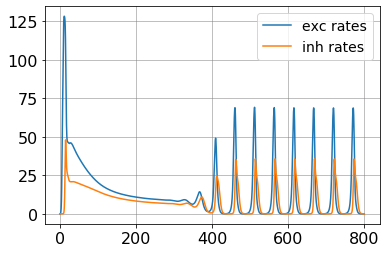

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

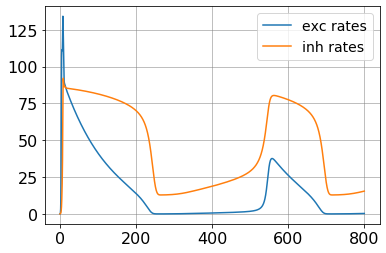

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

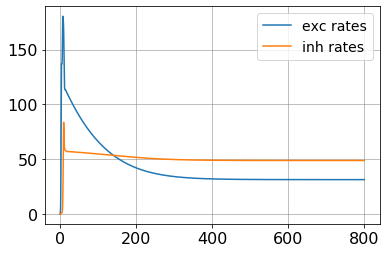

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

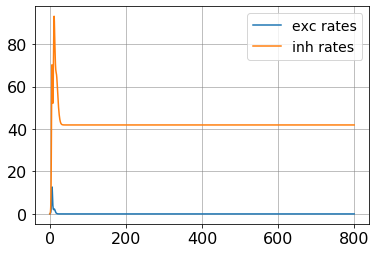

[4.4580e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [8]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 5000
set_params_slow()
initVars = slow_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
                    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5 ]

sheet = "C_b_"

target_rates = np.array( [down_rates[0], down_rates[1]])

In [9]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

In [10]:
# B.0.a)

dur = 1500
dur_pre = 100
dur_post = 100
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

## 1

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  50.7604443566146
RUN  2 , total integrated cost =  47.062761090267585
RUN  3 , total integrated cost =  38.19018247323456
RUN  4 , total integrated cost =  30.764114036833877
RUN  5 , total integrated cost =  26.62456482154474
RUN  6 , total integrated cost =  4.136614252122513
RUN  7 , total integrated cost =  1.7463502960303567
RUN  8 , total integrated cost =  0.1407900086853639
RUN  9 , total integrated cost =  0.01431750996175983
RUN  10 , total integrated cost =  0.0005001746942573625
RUN  11 , total integrated cost =  3.3980384531980083e-06
RUN  12 , total integrated cost =  3.635014593989161e-07
RUN  13 , total integrated cost =  1.7388477733234924e-08
RUN  14 , total integrated cost =  3.2083079610525043e-09
RUN  15 , total integrated cost =  2.4162643726378993e-17
RUN  16 , total integrated c

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 max iteration reached, step size =  1.6401064715739963e-141
RUN  17 , total integrated cost =  2.4153762584048975e-17
Control only changes marginally.
RUN  17 , total integrated cost =  2.4153762584048975e-17
Improved over  17  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -81.18634218060225 -81.02111046165749


C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:2352: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:2200: RuntimeWarning: invalid value encountered in double_scalars
  return abs(x - np.round(x)) < 1e-10
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:1123: RuntimeWarning: invalid value encountered in double_scalars
  coeff = np.round(x / b ** exponent)
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:2352: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:2200: RuntimeWarning: invalid value encountered in double_scalars
  return abs(x - np.round(x)) < 1e-10
C:\Users\lenas\anaconda3\lib\site-packages\matplotlib\ticker.py:1123: RuntimeWarning: invalid value encountered in double_scalars
  coeff = np.round(x / b ** exponent)


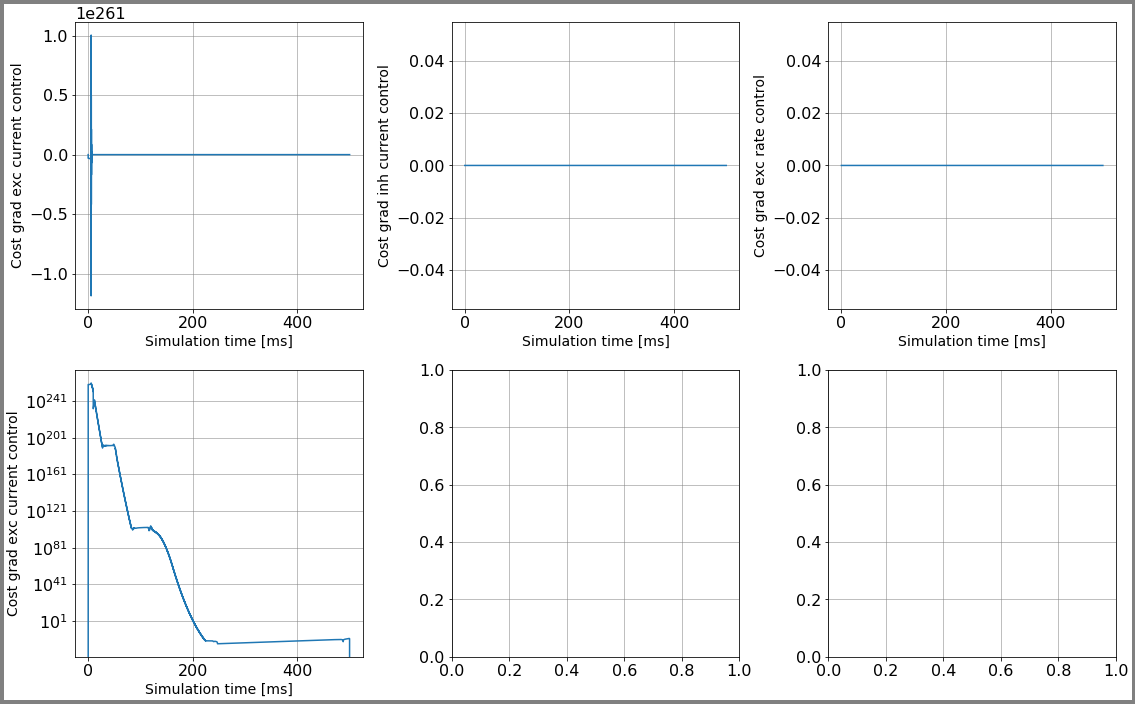

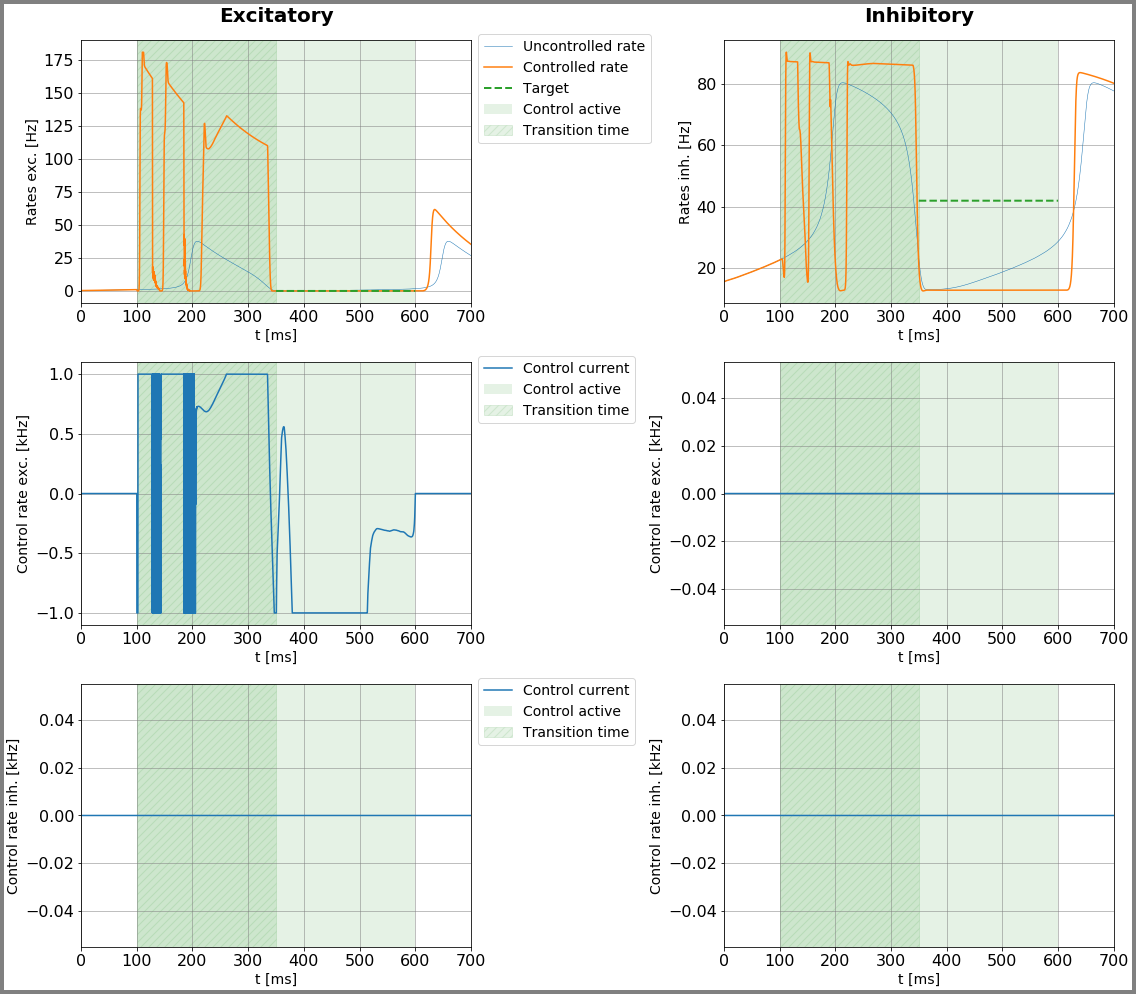

In [25]:
case_ind = 1
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 200

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.793336333878
RUN  2 , total integrated cost =  50.45638423201447
RUN  3 , total integrated cost =  48.92983543886496
RUN  4 , total integrated cost =  48.17413088367054
RUN  5 , total integrated cost =  47.37247279255281
RUN  6 , total integrated cost =  46.725750628413515
RUN  7 , total integrated cost =  45.995208149118184
RUN  8 , total integrated cost =  45.291004204839204
RUN  9 , total integrated cost =  44.5030756821373
RUN  10 , total integrated cost =  44.055938929104826
RUN  11 , total integrated cost =  43.5133020668537
RUN  12 , total integrated cost =  43.08864086509519
RUN  13 , total integrated cost =  42.58674176002722
RUN  14 , total integrated cost =  41.97076218934606
RUN  15 , total integrated cost =  41.30045876572673
RUN  16 , total integrated cost =  40.565627544641046
RUN  17 , total integrated cost =  39.97428597024719


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  175 , total integrated cost =  38.03448023611291
Improved over  175  iterations by  40.412557201913415  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -60.74210188764923 -60.735837330190165


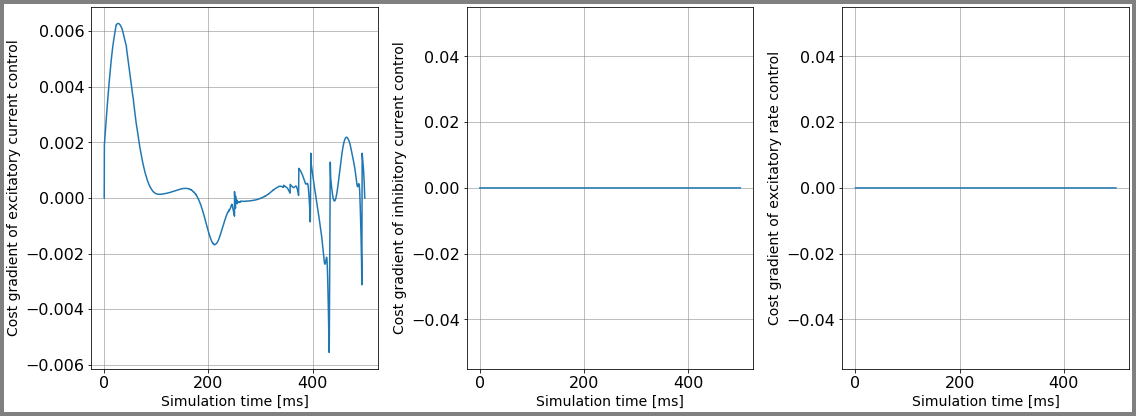

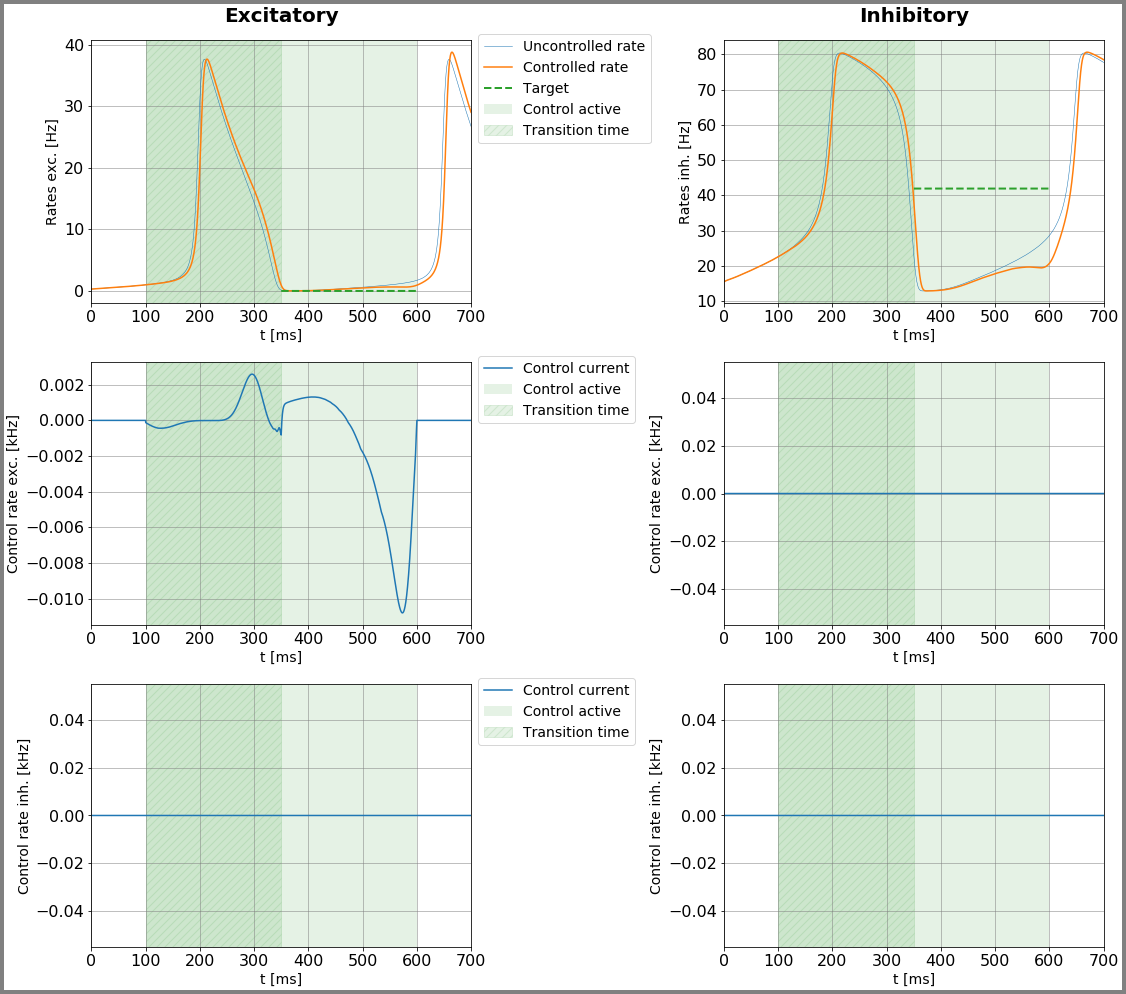

In [12]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 1
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 3

set cost params
control input:  [0] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  183324.9307888079
Gradient descend method:  CD


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  183324.9307888079
Control only changes marginally.
RUN  1 , total integrated cost =  183324.9307888079
Improved over  1  iterations in  0.6455164999999852  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -57.06523960372015 -57.0552311154448


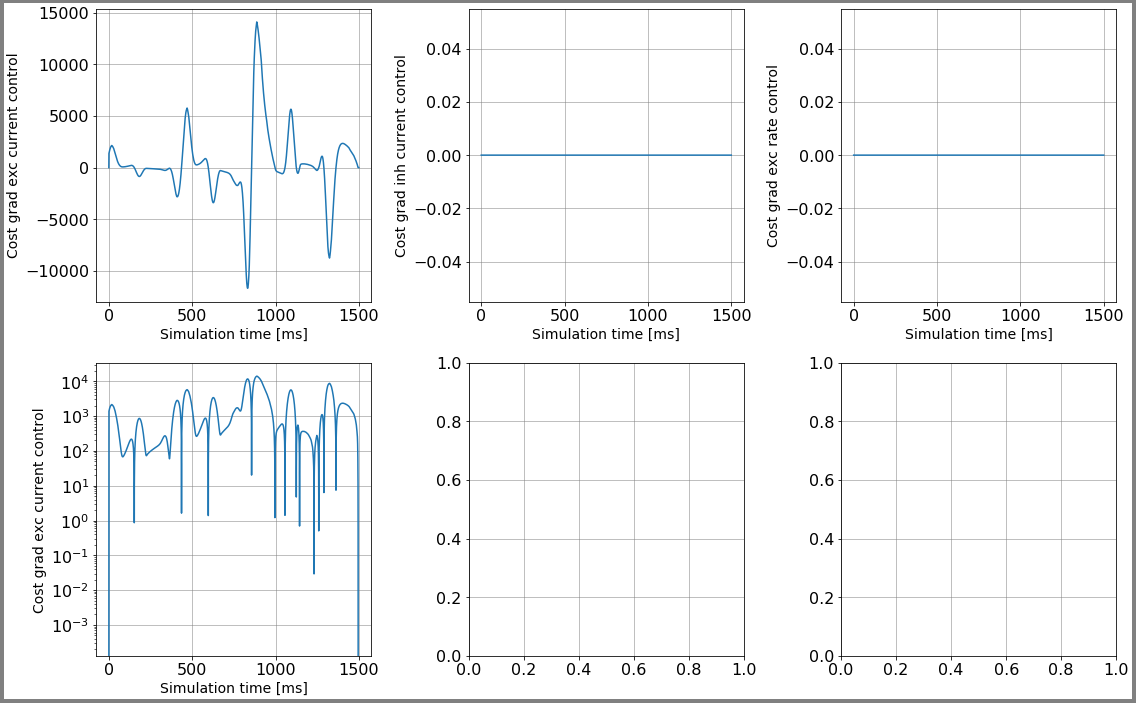

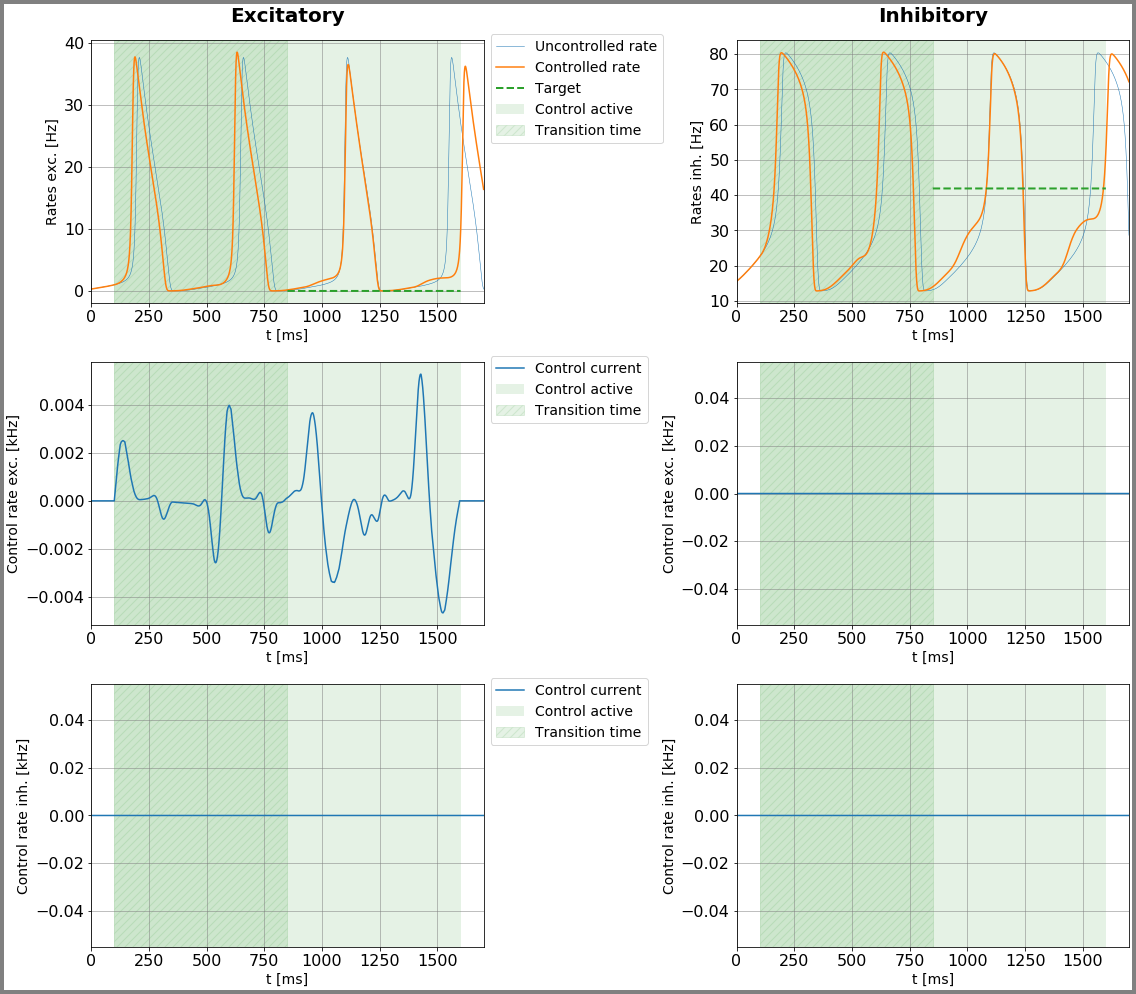

In [21]:
case_ind = 3
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0[0,0,:7500] = 5.
#control0[0,0,7500:] = - 5.
#control0[0,0,:7500] = - 5. #- bestStatea[0,0,n_pre-1:-n_post+1] / 8.
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = "CD"
max_it = 100

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  226988.5736180166
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  226988.5736180166
Control only changes marginally.
RUN  1 , total integrated cost =  226988.5736180166
Improved over  1  iterations in  0.7771979000000329  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -56.639365506781495 -56.639904309500324


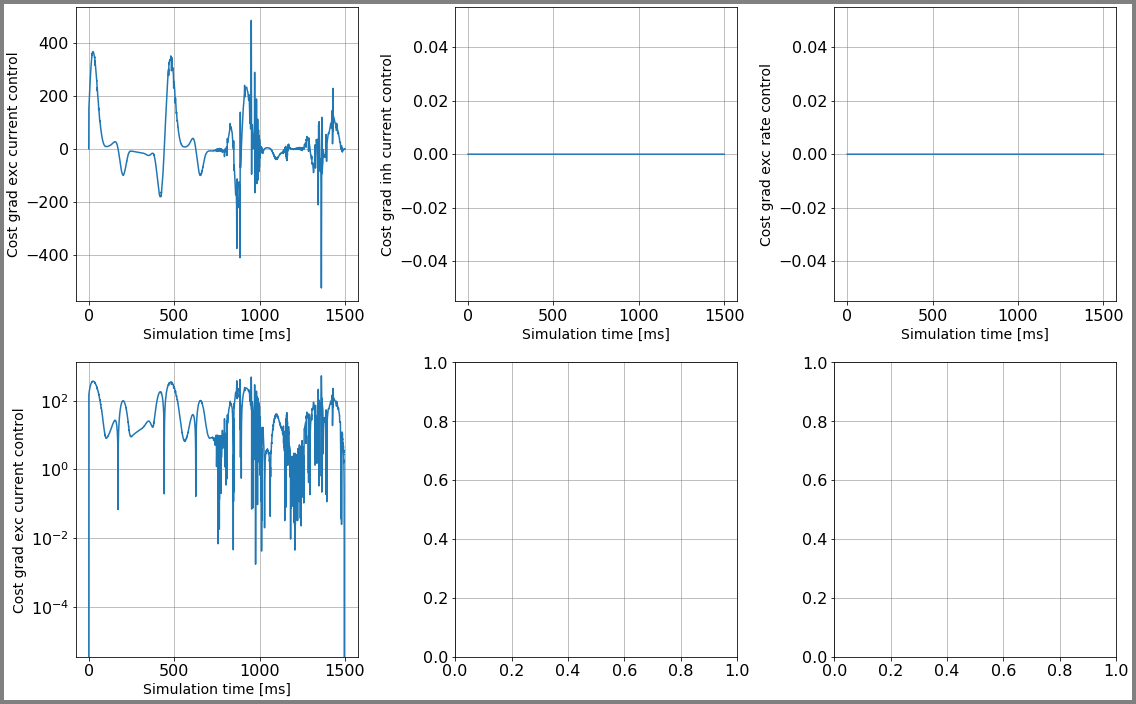

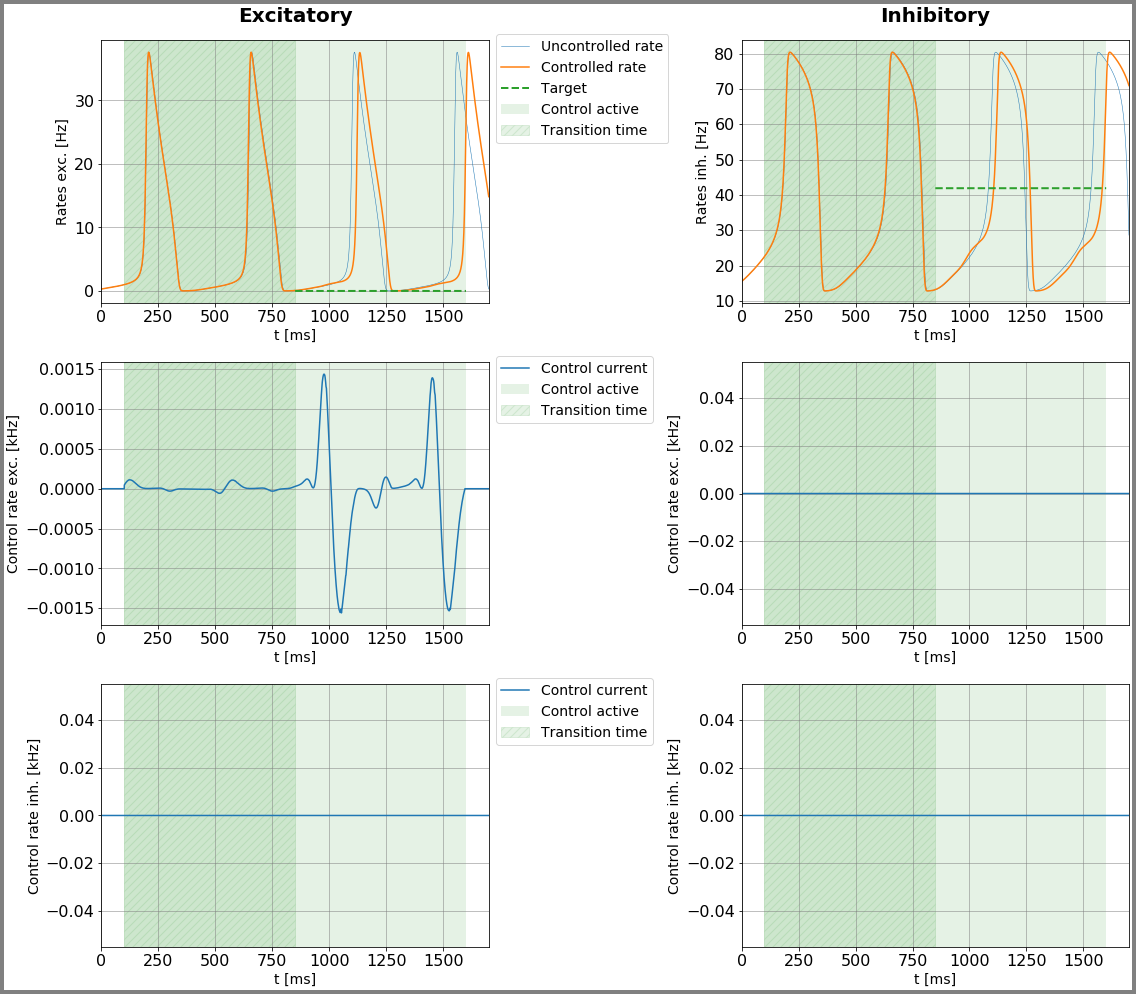

In [30]:
case_ind = 3
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 2. * 1e5, 2. * 1e5)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 5

In [ ]:
# A.4.a)

case_ind = 5
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  42194.29441539813
RUN  1 , total integrated cost =  40993.388458386806
RUN  2 , total integrated cost =  32640.65217679402
RUN  3 , total integrated cost =  22395.921831819833
RUN  4 , total integrated cost =  19618.468838485856
RUN  5 , total integrated cost =  2184.7906031402
RUN  6 , total integrated cost =  511.50419669802403
RUN  7 , total integrated cost =  446.4717118367025
RUN  8 , total integrated cost =  98.29107138313809
RUN  9 , total integrated cost =  36.69081450966459
RUN  10 , total integrated cost =  20.949339322566377
RUN  11 , total integrated cost =  4.61944236996153
RUN  12 , total integrated cost =  0.7260462237137486
RUN  13 , total integrated cost =  0.19360094089883872
RUN  14 , total integrated cost =  0.03580649062136079
RUN  15 , total integrated cost =  0.017582905432921993
RUN  16 , total integrated cost =  0.003061376933702

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.222203975898815
RUN  2 , total integrated cost =  49.80261244179735
RUN  3 , total integrated cost =  48.296041359152305
RUN  4 , total integrated cost =  47.53091802892568
RUN  5 , total integrated cost =  46.723862799950766
RUN  6 , total integrated cost =  46.14622366154432
RUN  7 , total integrated cost =  45.522683595140656
RUN  8 , total integrated cost =  45.07507231216043
RUN  9 , total integrated cost =  44.55508395692323
RUN  10 , total integrated cost =  44.194362162084204
RUN  11 , total integrated cost =  43.8154262157795
RUN  12 , total integrated cost =  43.54733234694897
RUN  13 , total integrated cost =  43.28693411423703
RUN  14 , total integrated cost =  43.064468886565635
RUN  15 , total integrated cost =  42.834763981700604
RUN  16 , total integrated cost =  42.6407264337322
RUN  17 , total integrated cost =  42.45124089095

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  171 , total integrated cost =  39.90740205299795
Improved over  171  iterations by  37.47830856919616  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -60.64239500595997 -60.63689703456109


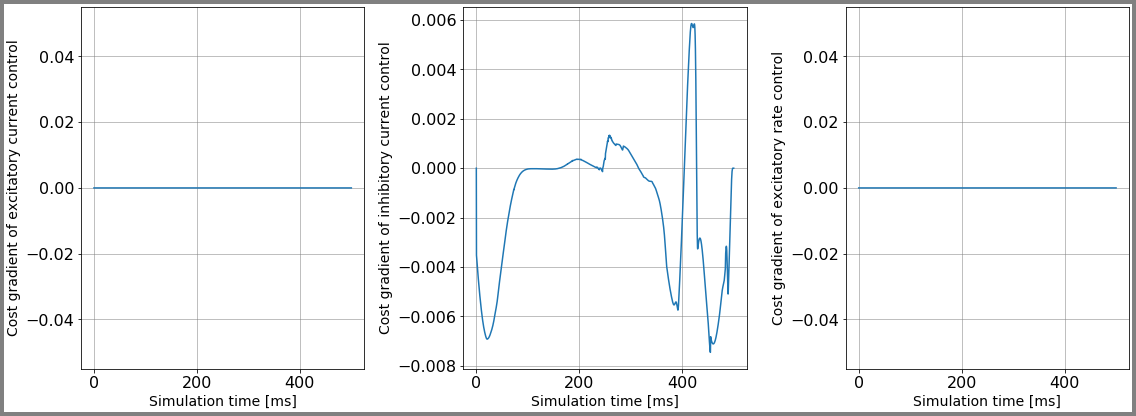

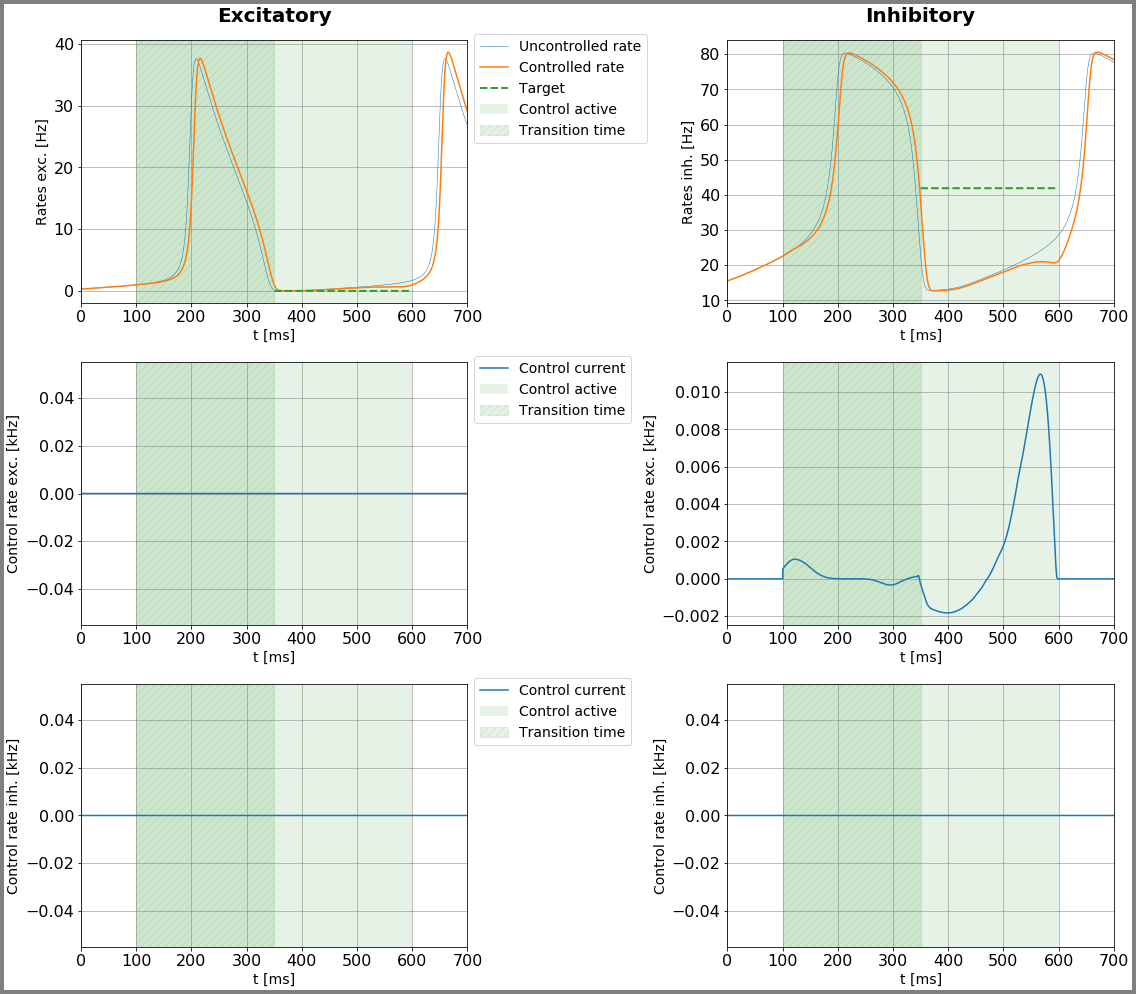

In [16]:
case_ind = 5
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 7

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  49.521063885572374
RUN  2 , total integrated cost =  44.29341899425212
RUN  3 , total integrated cost =  33.78746318625273
RUN  4 , total integrated cost =  16.491501216888512
RUN  5 , total integrated cost =  12.731404071942363
RUN  6 , total integrated cost =  1.4850009804545978
RUN  7 , total integrated cost =  0.1874681460516218
RUN  8 , total integrated cost =  0.0276843128632469
RUN  9 , total integrated cost =  0.00618429649764602
RUN  10 , total integrated cost =  0.0008469132613317922
RUN  11 , total integrated cost =  0.0001168541525259922
RUN  12 , total integrated cost =  1.4058265181424835e-05
RUN  13 , total integrated cost =  2.1377270781861296e-06
RUN  14 , total integrated cost =  3.1944738069049786e-07
RUN  15 , total integrated cost =  4.6960990412087964e-08
RUN  16 , total integr

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  23 , total integrated cost =  2.3498811221104322e-17
Improved over  23  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198


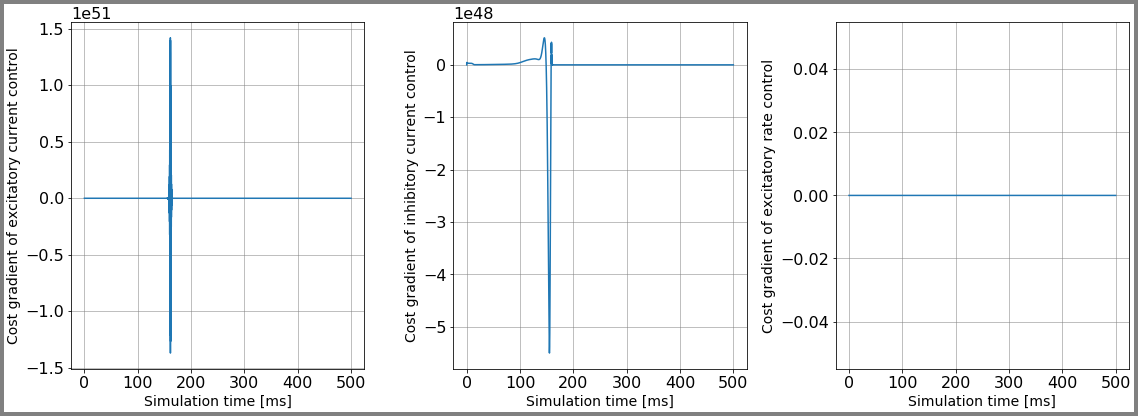

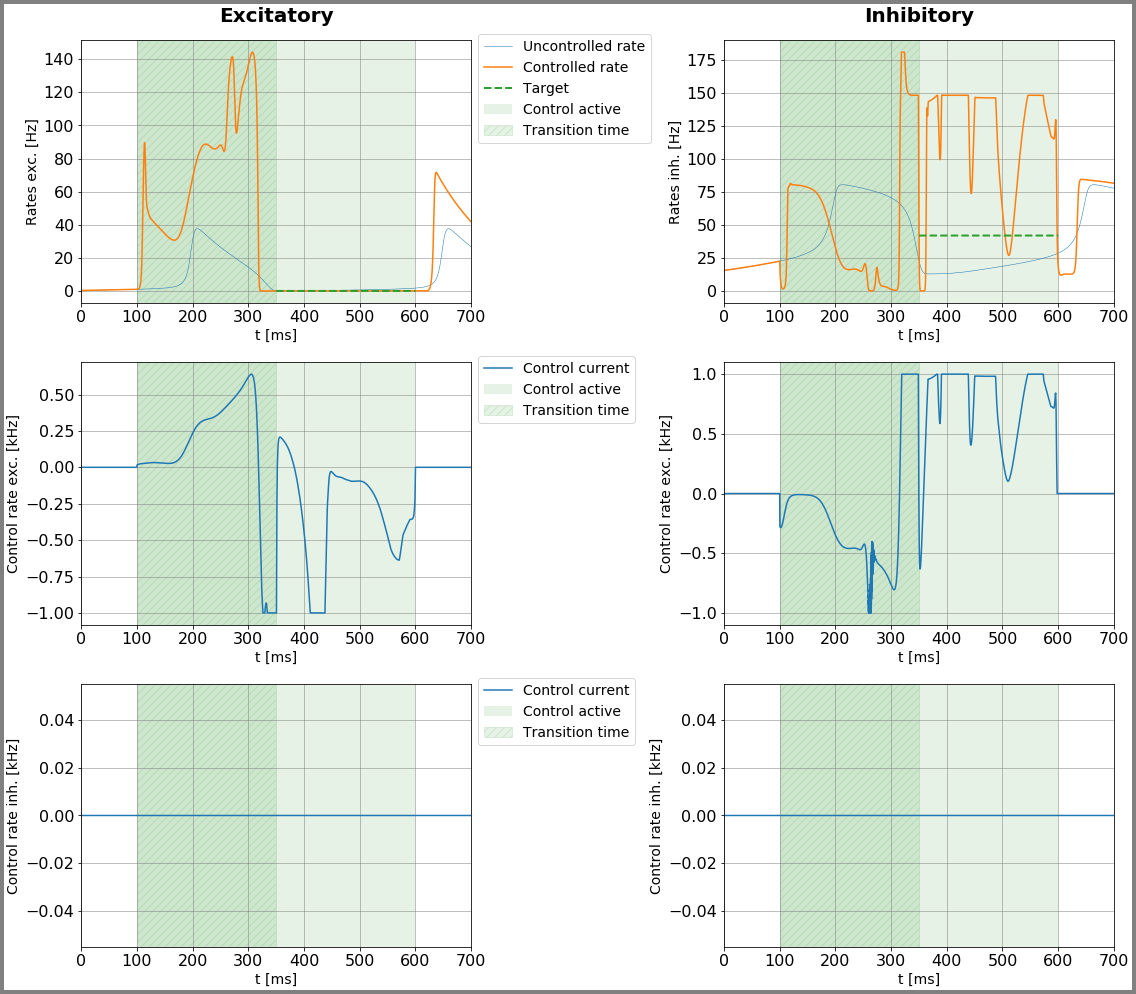

In [17]:
# A.6.a)
case_ind = 7
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.222203975898815
RUN  2 , total integrated cost =  49.798045328038285
RUN  3 , total integrated cost =  48.2900523251189
RUN  4 , total integrated cost =  47.40133398079629
RUN  5 , total integrated cost =  46.43085991503662
RUN  6 , total integrated cost =  45.820908131101625
RUN  7 , total integrated cost =  45.14170761208009
RUN  8 , total integrated cost =  44.64709663388015
RUN  9 , total integrated cost =  44.105795395820074
RUN  10 , total integrated cost =  43.73747683675775
RUN  11 , total integrated cost =  43.339217761177345
RUN  12 , total integrated cost =  42.91109791198566
RUN  13 , total integrated cost =  42.42498965203981
RUN  14 , total integrated cost =  41.889061914847424
RUN  15 , total integrated cost =  41.35179323766258
RUN  16 , total integrated cost =  41.17926649778656
RUN  17 , total integrated cost =  41.00040829130

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  126 , total integrated cost =  37.54822369247924
Improved over  126  iterations by  41.17436027636311  percent.
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095828290198
Problem in initial value trasfer:  Vmean_exc -60.77919081635182 -60.77282447289306


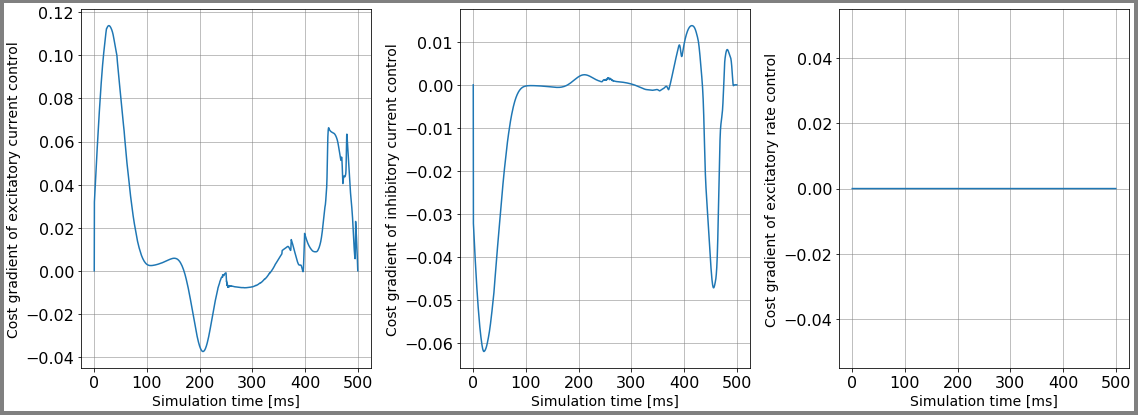

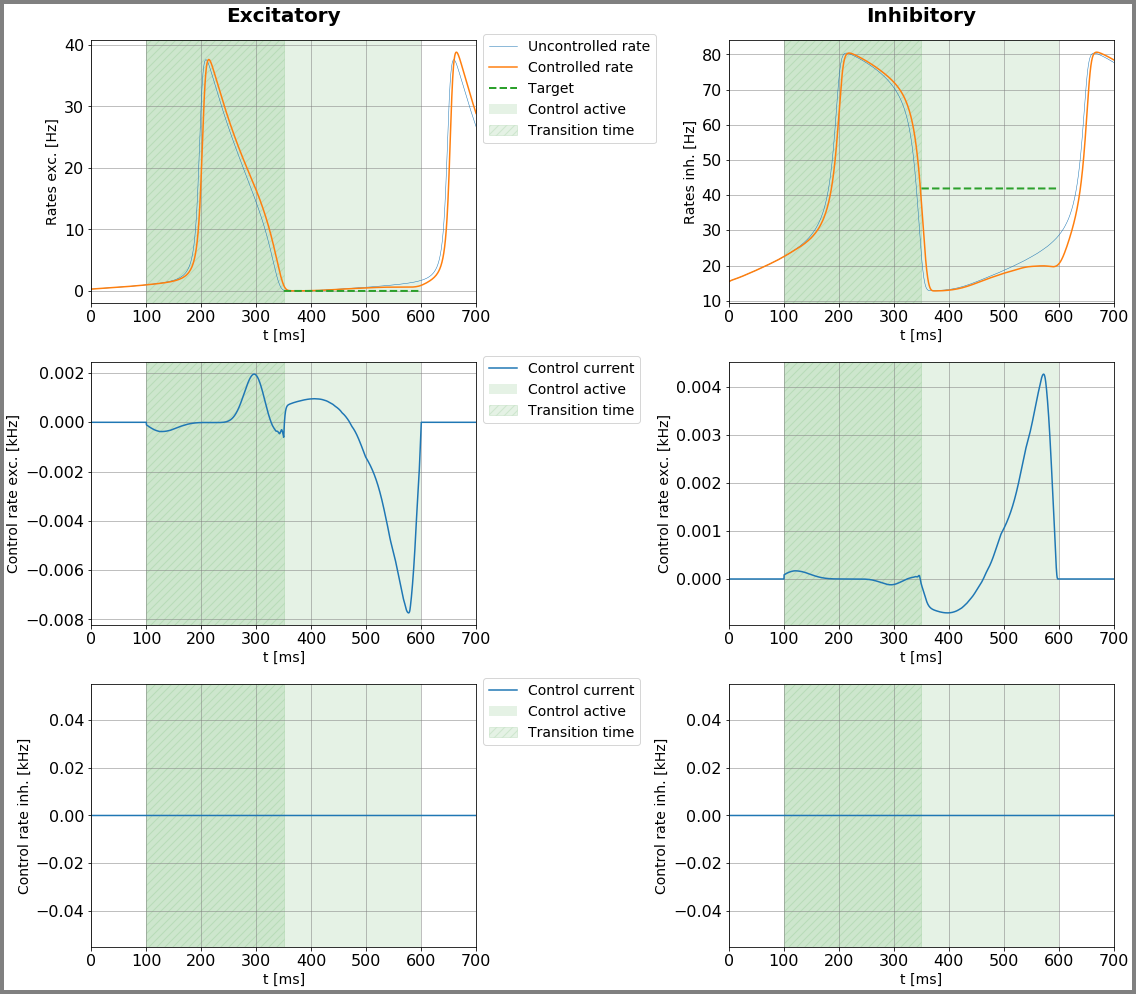

In [18]:
case_ind = 7
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 9

set cost params
control input:  [0, 2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  178919.2625677673


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  178919.2625677673
Control only changes marginally.
RUN  1 , total integrated cost =  178919.2625677673
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5667300441015535
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095146364495
Problem in initial value trasfer:  tau_exc 14.884010616351775 14.884073315797682
Problem in initial value trasfer:  Vmean_exc -57.18013997869096 -57.170487299008876


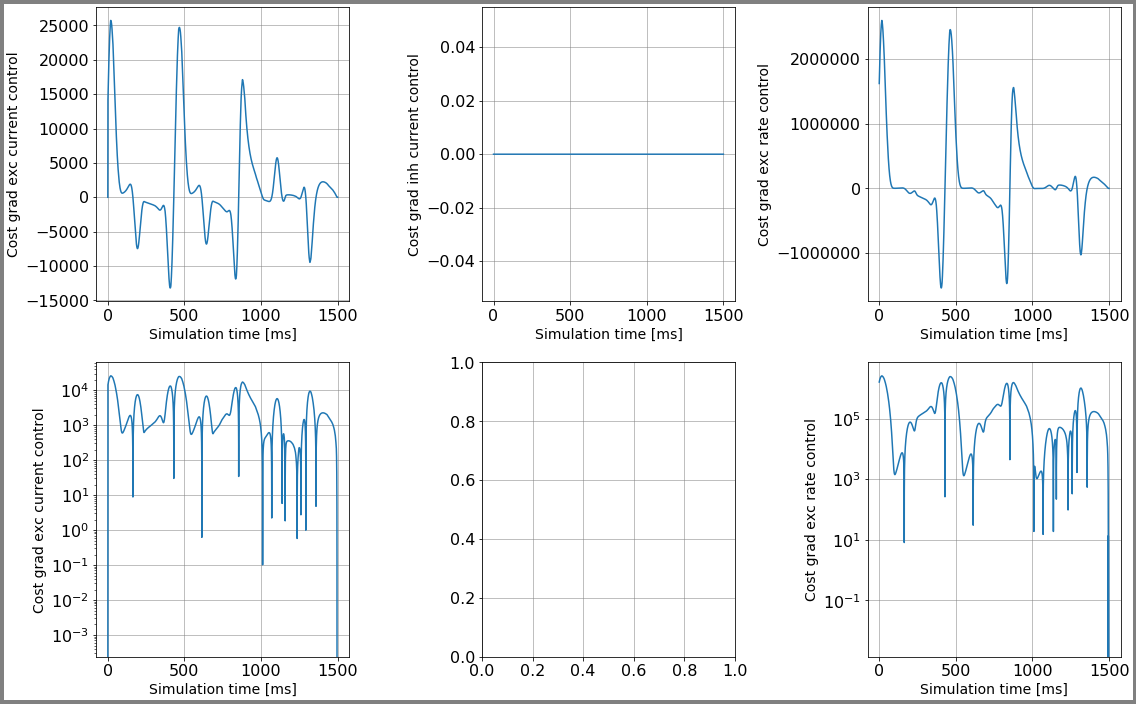

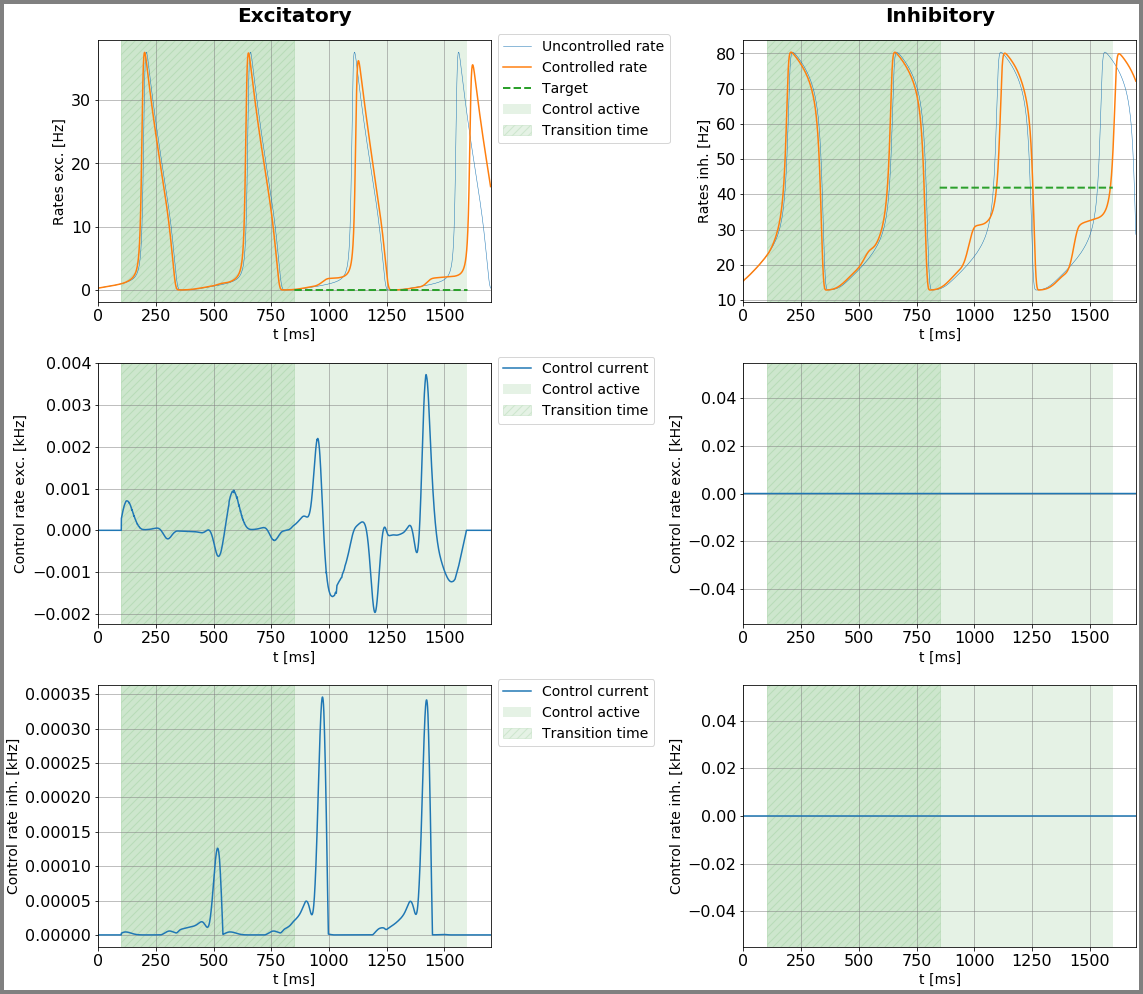

In [48]:
# A.8.a)
case_ind = 9
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0[0,0,:100] = -5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = "FR"

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.793336333878
RUN  2 , total integrated cost =  50.45638423201447
RUN  3 , total integrated cost =  46.96884496652877
RUN  4 , total integrated cost =  41.25619523997098
RUN  5 , total integrated cost =  38.754412477165204
RUN  6 , total integrated cost =  36.50692959069962
RUN  7 , total integrated cost =  36.278823337237476
RUN  8 , total integrated cost =  35.444417045318616
RUN  9 , total integrated cost =  34.54359310874364
RUN  10 , total integrated cost =  34.36788174355688
RUN  11 , total integrated cost =  33.94892164349723
RUN  12 , total integrated cost =  33.59710718171118
RUN  13 , total integrated cost =  33.54207513453429
RUN  14 , total integrated cost =  33.29081416792376
RUN  15 , total integrated cost =  33.17502667412432
RUN  16 , total integrated cost =  33.10983434398376
RUN  17 , total integrated cost =  32.964277104365664

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  79 , total integrated cost =  30.923613786815466
Improved over  79  iterations by  51.55293154545534  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5667320471019917
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61095429813288
Problem in initial value trasfer:  tau_exc 14.884010616351775 14.884047254195902
Problem in initial value trasfer:  Vmean_exc -60.83703437754855 -60.83521851254697


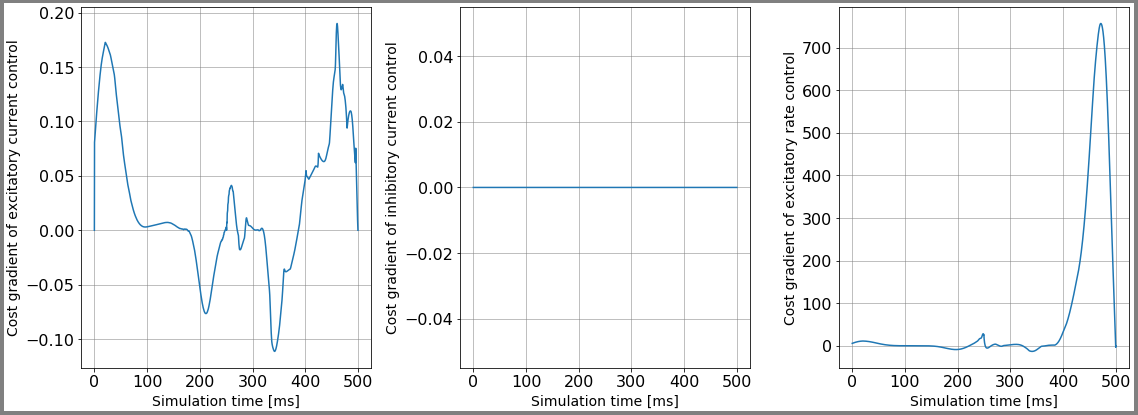

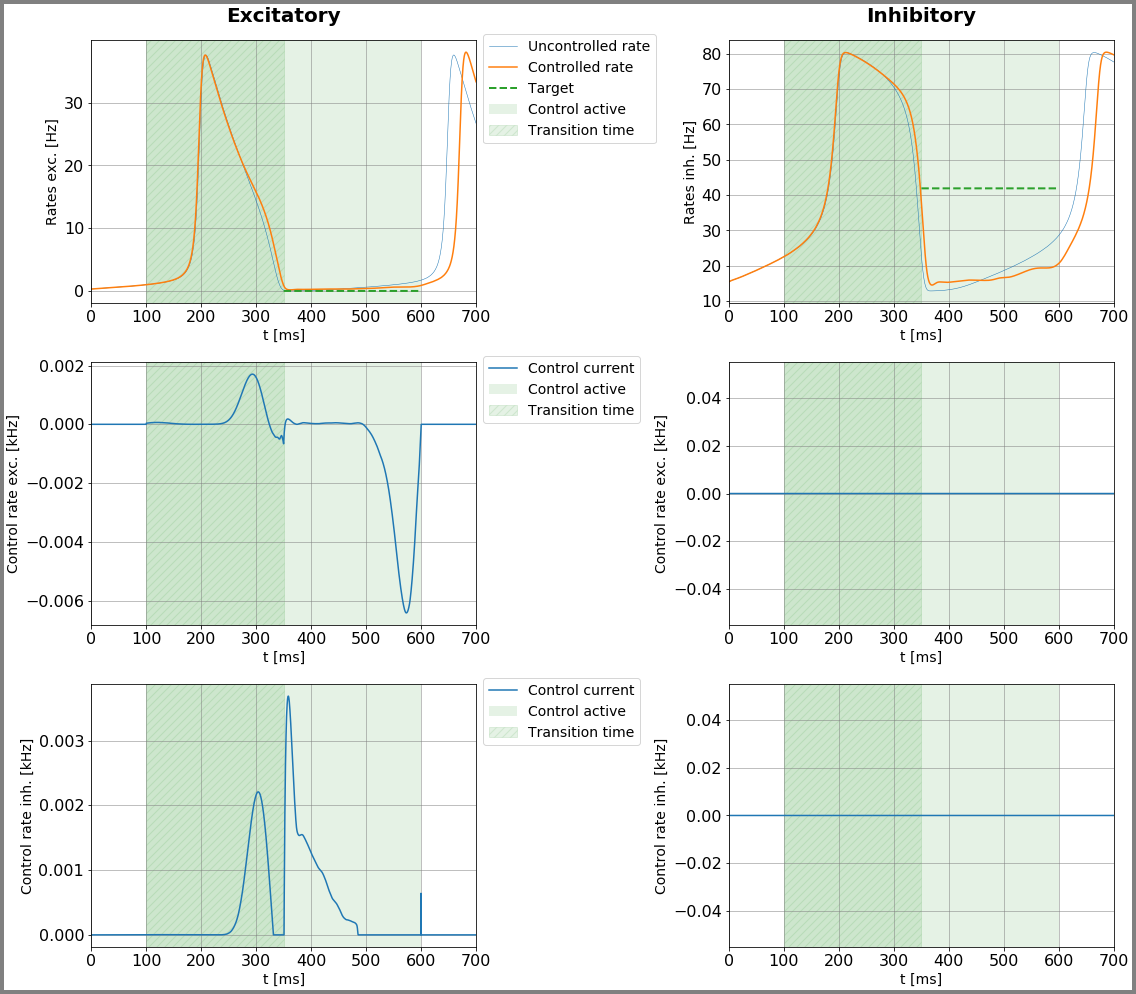

In [20]:
case_ind = 9
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 11

set cost params
control input:  [1, 2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  180587.65448963785
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  180587.65448963785
Control only changes marginally.
RUN  1 , total integrated cost =  180587.65448963785
Improved over  1  iterations in  3.209372799999983  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5667065300619307
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.610918188446746
Problem in initial value trasfer:  tau_exc 14.884010616351775 14.8843792635774
Problem in initial value trasfer:  Vmean_exc -57.22215006105006 -57.21308730383991


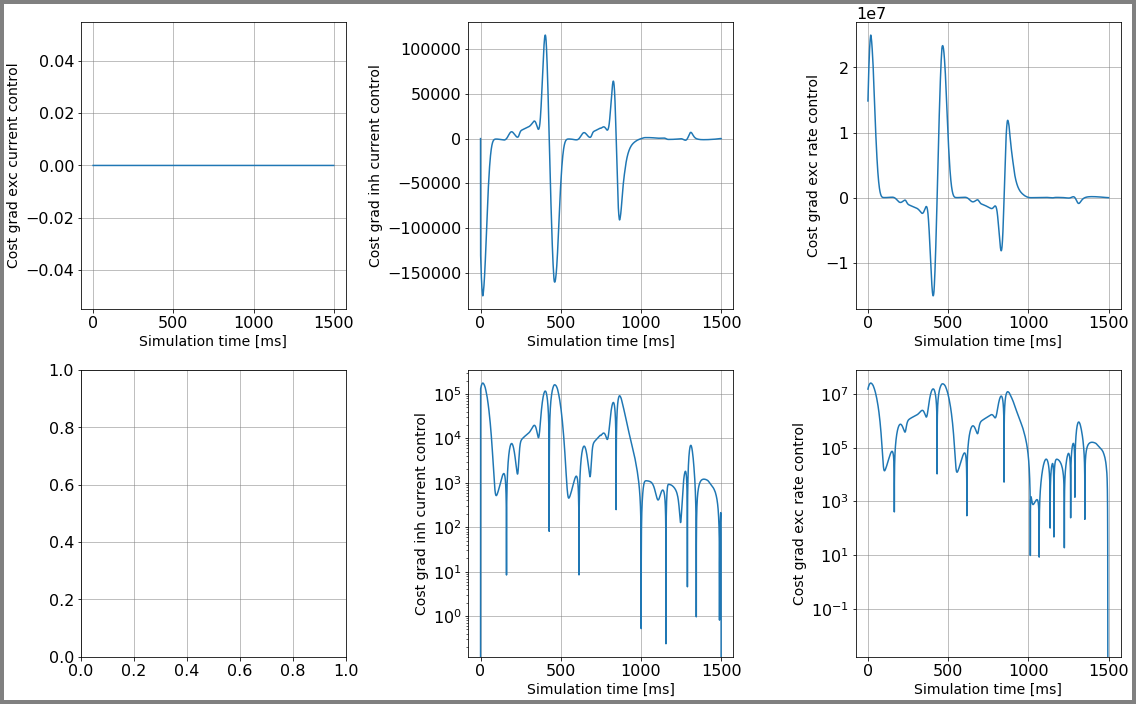

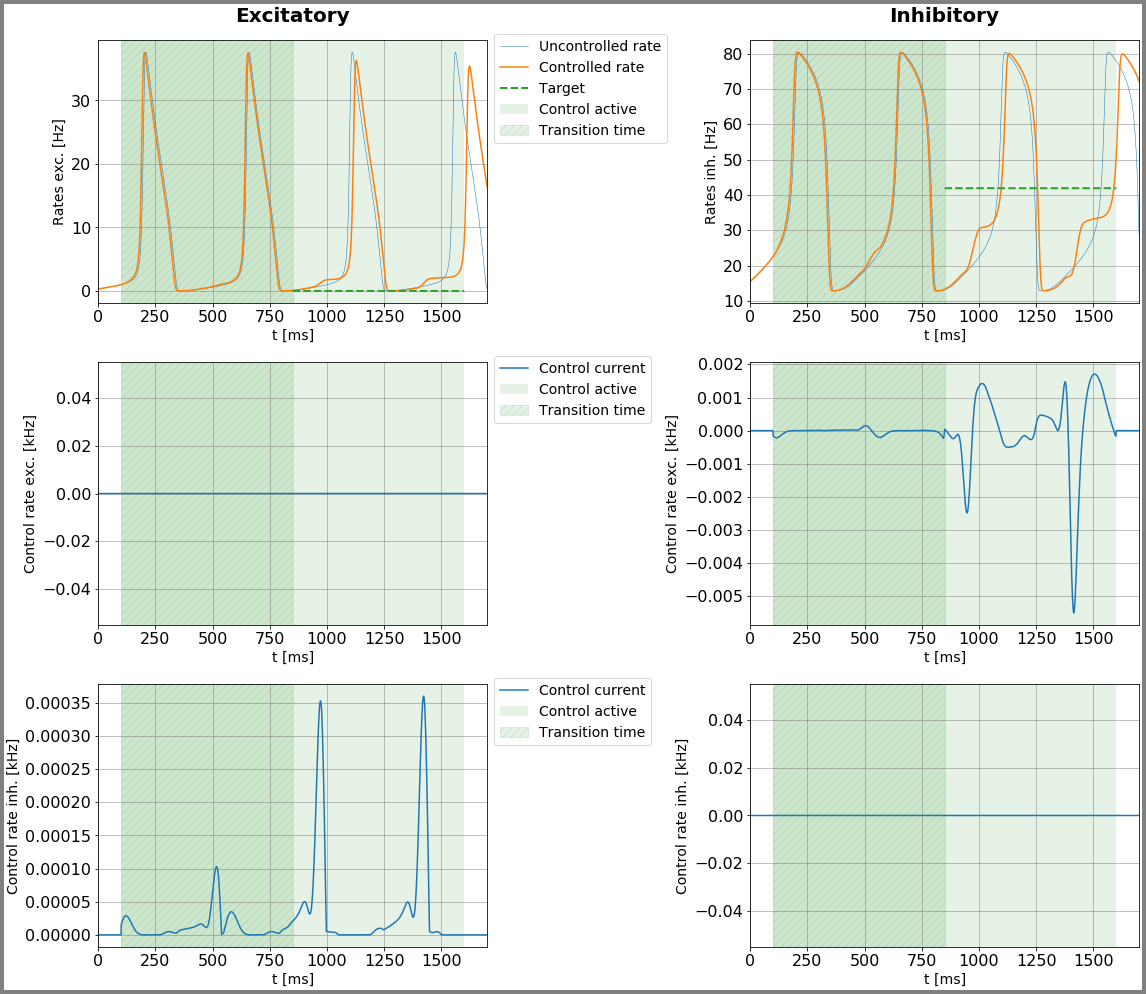

In [47]:
# A.10.a)
case_ind = 11
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 1000

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  191087.5327948758
Gradient descend method:  None
RUN  1 , total integrated cost =  191087.53279487576
State only changes marginally.


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  191087.53279487576
Control only changes marginally.
RUN  2 , total integrated cost =  191087.53279487576
Improved over  2  iterations in  6.182859799999278  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5667029418404663
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.61091311068179
Problem in initial value trasfer:  tau_exc 14.884010616351775 14.884425950935583
Problem in initial value trasfer:  Vmean_exc -56.919493477167535 -56.9105708033518


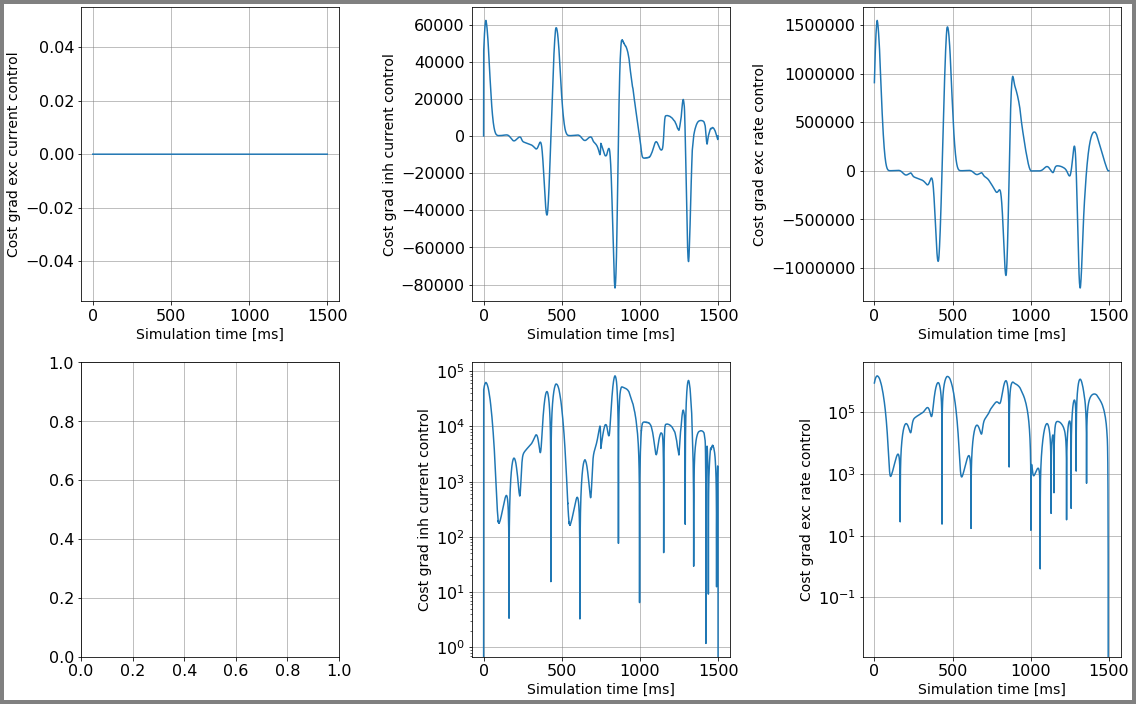

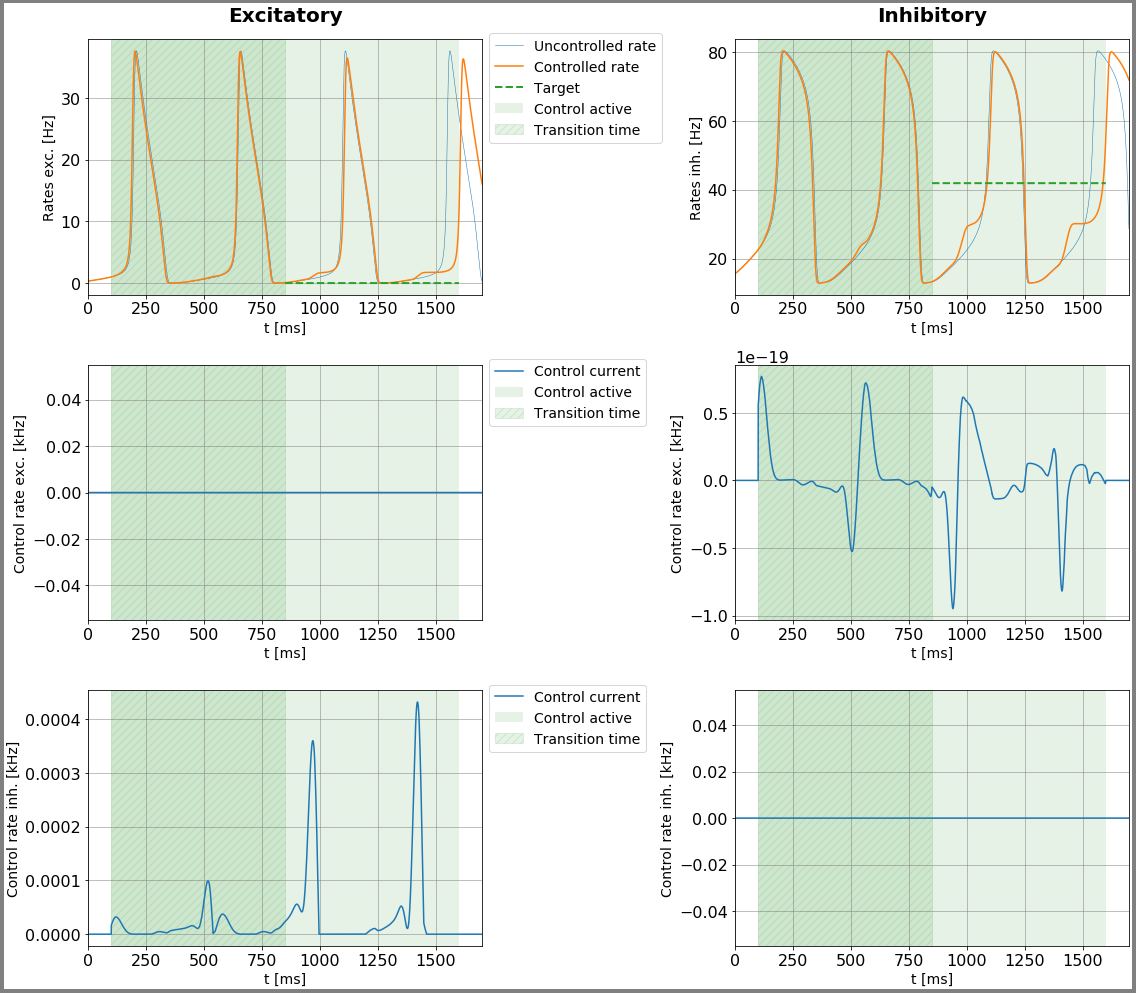

In [50]:
case_ind = 11
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e6, 1e6)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None
max_it = 1000

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  2.4802282952983123e-17
RUN  2 , total integrated cost =  2.480228258118777e-17
RUN  3 , total integrated cost =  2.4802282560264027e-17
RUN  4 , total integrated cost =  2.4802242304403905e-17
RUN  5 , total integrated cost =  2.4801083677158953e-17
RUN  6 , total integrated cost =  2.4792360718174653e-17
RUN  7 , total integrated cost =  2.4792341050315413e-17
RUN  8 , total integrated cost =  2.4792341049874742e-17
RUN  9 , total integrated cost =  2.4765910996540547e-17


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  2.4765910996540547e-17
Control only changes marginally.
RUN  10 , total integrated cost =  2.4765910996540547e-17
Improved over  10  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.5295727170742817
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.55836937325112
Problem in initial value trasfer:  tau_exc 14.884010616351775 15.367537743292699


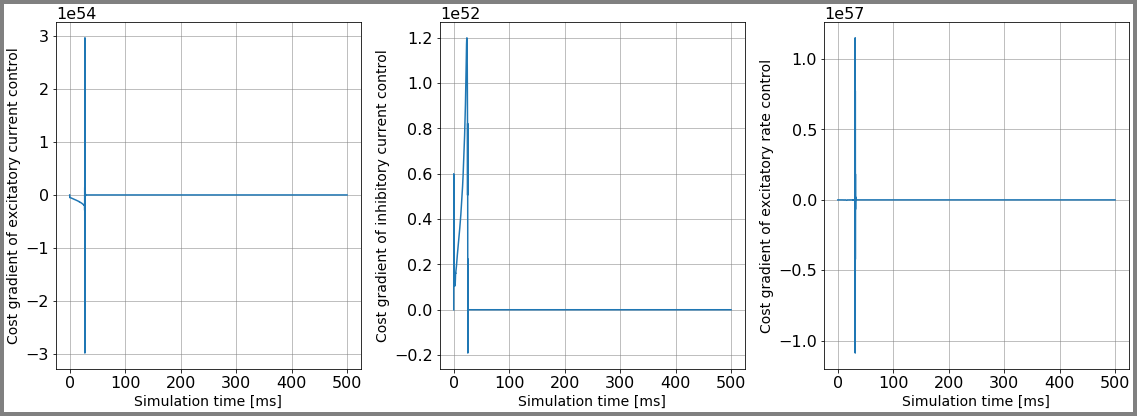

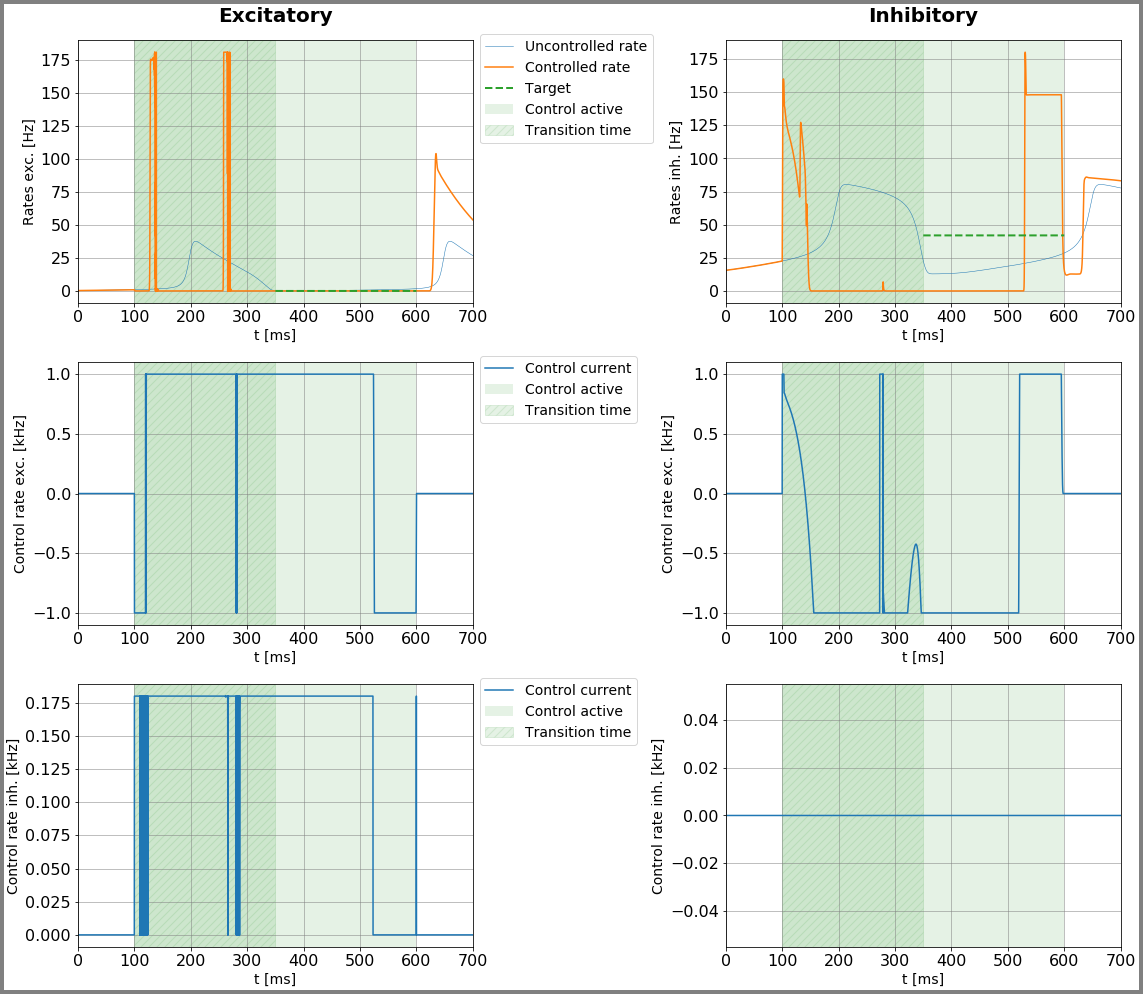

In [23]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  63.829690367807224
RUN  1 , total integrated cost =  51.222203975898815
RUN  2 , total integrated cost =  49.80261244179735
RUN  3 , total integrated cost =  46.291915091941654
RUN  4 , total integrated cost =  40.599592880098626
RUN  5 , total integrated cost =  38.33753478588997
RUN  6 , total integrated cost =  36.216310254454484
RUN  7 , total integrated cost =  33.8929740833154
RUN  8 , total integrated cost =  33.07603096642063
RUN  9 , total integrated cost =  32.7132391769871
RUN  10 , total integrated cost =  32.25348314866228
RUN  11 , total integrated cost =  32.18438542307515
RUN  12 , total integrated cost =  31.967892580850616
RUN  13 , total integrated cost =  31.878534216272666
RUN  14 , total integrated cost =  31.81631757153808
RUN  15 , total integrated cost =  31.687150861050092
RUN  16 , total integrated cost =  31.634088416558168
RUN  17 , total integrated cost =  31.5164958339

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  127 , total integrated cost =  30.65535962006616
Improved over  127  iterations by  51.97319704447866  percent.
Problem in initial value trasfer:  sigmae_f 1.5667348629541586 1.566730868793417
Problem in initial value trasfer:  Vmean_exc -60.61252911489295 -60.610952630679286
Problem in initial value trasfer:  tau_exc 14.884010616351775 14.88406258550001
Problem in initial value trasfer:  Vmean_exc -60.8661896640328 -60.865407816574944


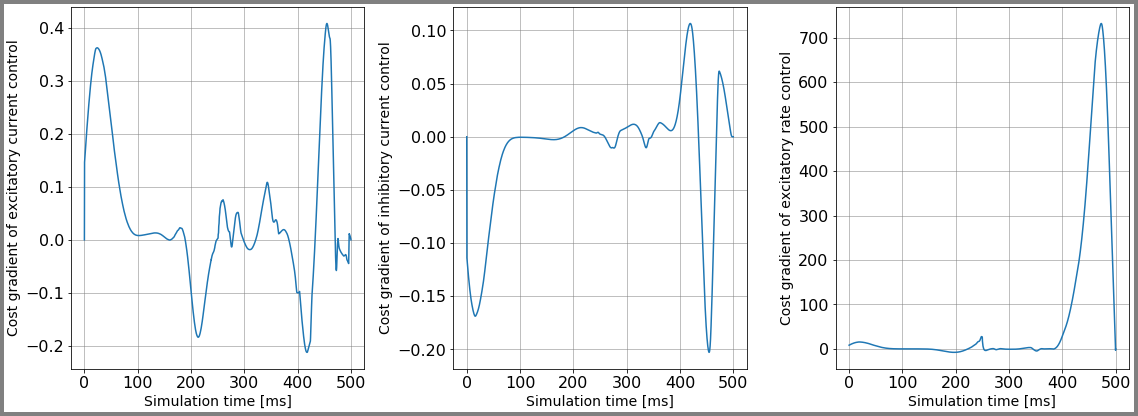

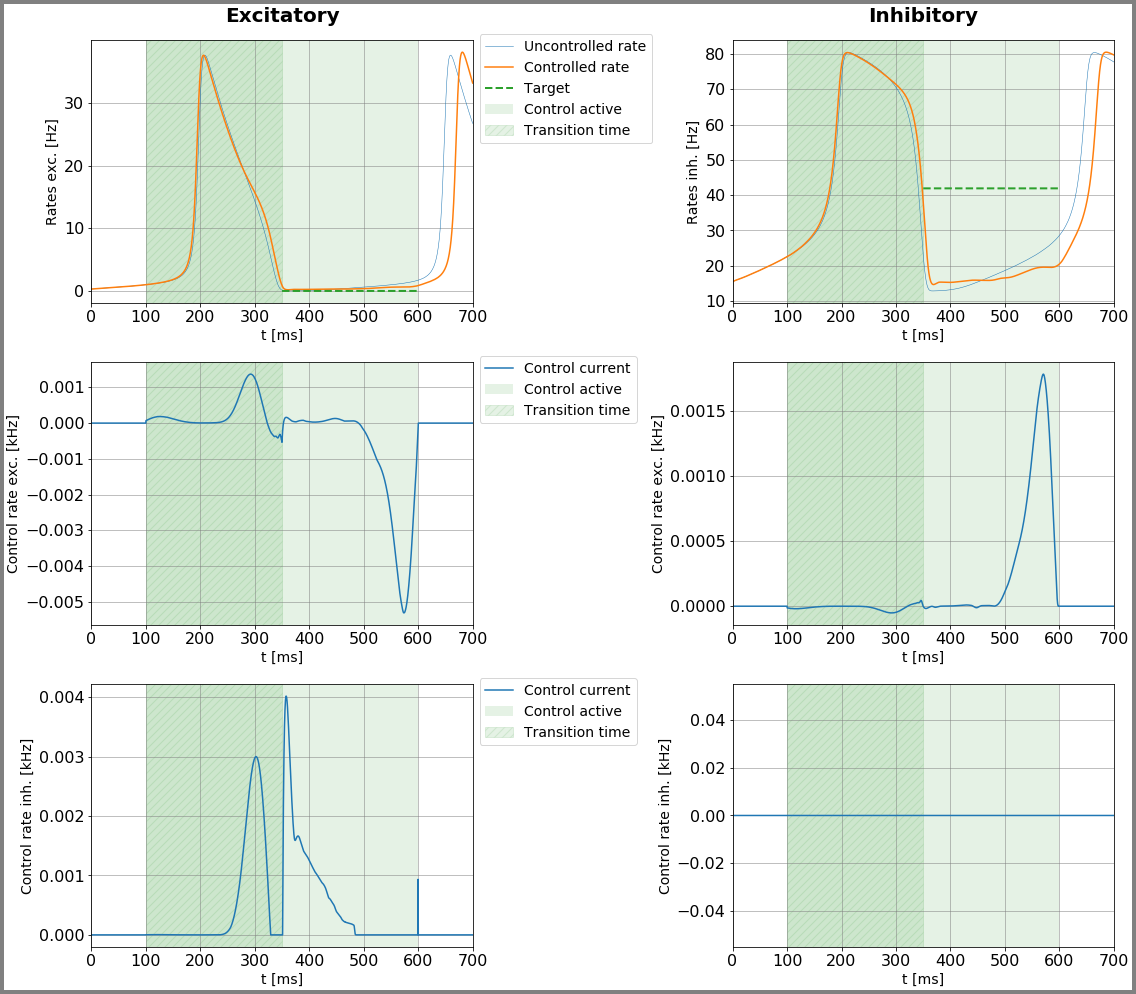

In [24]:
case_ind = 12
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )